In [2]:
# =========================
# XCM analysis notebook (CSV) — Axelar-style tables + charts
# Includes: latency quantiles, status + reliability, costs (RAW + assumed USD),
# per-chain breakdowns, outliers, and LaTeX exports.
#
# Assumption for USD conversion:
# - cost is in Planck (1e-10 DOT)
# - DOT spot price: 1 DOT = 1.3387 USD (18.2.2026 15:30)
# If your "cost" is actually in a parachain-native token, USD results are only an approximation.
# =========================
!pip3 install matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
  Using cached fonttools-4.60.2-cp39-cp39-macosx_10_9_universal2.whl (2.9 MB)
  Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
     |████████████████████████████████| 122 kB 6.8 MB/s eta 0:00:01
  Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.


Matplotlib is building the font cache; this may take a moment.


In [3]:
# -------------------------
# 0) Config
# -------------------------
PATH = "corrected_xcm_pairs_multichain.csv"   # adjust path if needed
DOT_USD = 1.3387                              # as of 18.2.2026 15:30
PLANCK_PER_DOT = 10_000_000_000               # 1 DOT = 10^10 planck
SUCCESS_LABEL = "Success"
MIN_N_PER_CHAIN = 10                          # for per-chain boxplots
SUSPICIOUS_USD_THRESHOLD = 10                 # flag fees above this (assumed USD)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

In [4]:
# -------------------------
# 1) Load
# -------------------------
df = pd.read_csv(PATH)
print("Rows, cols:", df.shape)
display(df.head(3))
print("\nColumns:\n", list(df.columns))

Rows, cols: (2559, 26)


,id_src,block_timestamp_src,event_index_src,extrinsic_index_src,phase_src,module_id_src,event_id_src,extrinsic_hash_src,finalized_src,dest_para_id,block_num_extracted,corr_id,id_dst,block_timestamp_dst,event_index_dst,extrinsic_index_dst,phase_dst,module_id_dst,event_id_dst,extrinsic_hash_dst,finalized_dst,dest_chain,source_chain,latency_s,cost,status
0,2199872500077,1723106964,21998725-77,21998725-5,0,xcmpallet,Sent,0xbe49507e7dc92faa877c4e884d277adb929f8837a71f...,True,1000.0,21998725,0xdb45c19633d4c27c557ac84eb8fe2586f1d01601ee0b...,686069900006,1723106976,6860699-6,NaN,2,messagequeue,Processed,0xa30dc95dd43e331d31d399223b5312b0d2d76c9d9908...,True,assethub,polkadot,12,181667896,Success
1,2199850000050,1723105608,21998500-50,21998500-2,0,xcmpallet,Sent,0x531fdb385283892817c47edbf91d3716e519074682bf...,True,1000.0,21998500,0x4fea5057e9ad8c771e6c5962aeaaf82713072f7f41ae...,686058800004,1723105620,6860588-4,NaN,2,messagequeue,Processed,0xb723c1e0b470aa853049117e8c3cad28ac31e19826b5...,True,assethub,polkadot,12,180667896,Success
2,2199657200065,1723094010,21996572-65,21996572-3,0,xcmpallet,Sent,0x70f3a5fc38edcfdc101d23c500d332468aeb6a5dfd94...,True,1000.0,21996572,0x26b99e84602ce13102ce80770cb2dd4508b314bcd0ad...,685963300005,1723094028,6859633-5,NaN,2,messagequeue,Processed,0xa318ca9f518ab41fe4c2a440e7ae7ee1e156d69e6231...,True,assethub,polkadot,18,181667896,Success



Columns:
 ['id_src', 'block_timestamp_src', 'event_index_src', 'extrinsic_index_src', 'phase_src', 'module_id_src', 'event_id_src', 'extrinsic_hash_src', 'finalized_src', 'dest_para_id', 'block_num_extracted', 'corr_id', 'id_dst', 'block_timestamp_dst', 'event_index_dst', 'extrinsic_index_dst', 'phase_dst', 'module_id_dst', 'event_id_dst', 'extrinsic_hash_dst', 'finalized_dst', 'dest_chain', 'source_chain', 'latency_s', 'cost', 'status']


In [5]:
# -------------------------
# 2) Cleanup / typing
# -------------------------
# Timestamps -> datetime
for c in ["block_timestamp_src", "block_timestamp_dst"]:
    if c in df.columns:
        df[c] = pd.to_datetime(df[c], errors="coerce", utc=True)

# Numerics
for c in ["latency_s", "cost", "dest_para_id", "event_index_src", "event_index_dst"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Normalize status & chain labels
if "status" in df.columns:
    df["status"] = df["status"].astype(str).str.strip()

for c in ["source_chain", "dest_chain"]:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip()

# Finalized flags normalization (bool)
for c in ["finalized_src", "finalized_dst"]:
    if c in df.columns:
        # handle True/False, 1/0, "true"/"false"
        s = df[c].astype(str).str.strip().str.lower()
        df[c] = s.map({"true": True, "false": False, "1": True, "0": False}).fillna(False)

# Drop rows missing essentials
essential = []
if "latency_s" in df.columns: essential.append("latency_s")
if "status" in df.columns: essential.append("status")
df_clean = df.dropna(subset=essential).copy() if essential else df.copy()

print("\nAfter cleanup rows:", len(df_clean))


After cleanup rows: 2559


In [6]:
# -------------------------
# 3) Data quality checks
# -------------------------
if "corr_id" in df_clean.columns:
    dup_corr = df_clean["corr_id"].duplicated().sum()
    print(f"Duplicated corr_id: {dup_corr} (0 is ideal)")
else:
    print("No corr_id column found (pairing key).")

if "block_timestamp_src" in df_clean.columns and "block_timestamp_dst" in df_clean.columns:
    miss_ts = df_clean[["block_timestamp_src", "block_timestamp_dst"]].isna().sum()
    print("\nMissing timestamps:\n", miss_ts)

Duplicated corr_id: 0 (0 is ideal)

Missing timestamps:
 block_timestamp_src    0
block_timestamp_dst    0
dtype: int64


In [7]:
# -------------------------
# 4) Latency — quantiles + summary
# -------------------------
lat = df_clean["latency_s"].dropna()
q50, q90, q99 = np.percentile(lat, [50, 90, 99])

latency_quantiles = pd.DataFrame({
    "Kvantil": ["p50", "p90", "p99"],
    "Latence [s]": [q50, q90, q99]
})
latency_quantiles["Latence [s]"] = latency_quantiles["Latence [s]"].map(lambda x: float(np.round(x, 2)))

print("\nLatency quantiles:")
display(latency_quantiles)

print("Latency summary:")
display(lat.describe(percentiles=[0.5, 0.9, 0.99]))


Latency quantiles:


,Kvantil,Latence [s]
0,p50,18.0
1,p90,18.0
2,p99,36.0


Latency summary:


count    2559.000000
mean       16.220399
std         5.146322
min        12.000000
50%        18.000000
90%        18.000000
99%        36.000000
max        66.000000
Name: latency_s, dtype: float64

In [8]:
# -------------------------
# 5) Status distribution + reliability
# -------------------------
status_counts = df_clean["status"].value_counts(dropna=False).rename_axis("Stav").reset_index(name="Počet")
print("\nStatus counts:")
display(status_counts)

def compute_reliability(sub: pd.DataFrame, success_label: str = SUCCESS_LABEL):
    """Reliability = Success / (Success + Failed).
    If explicit 'Failed' exists, use it.
    Otherwise treat any non-success as 'failed-like' for the ratio (conservative)."""
    statuses = sub["status"].fillna("NA")

    succ = (statuses == success_label).sum()

    if (statuses == "Failed").any():
        fail = (statuses == "Failed").sum()
    else:
        fail = (statuses != success_label).sum()

    denom = succ + fail
    return (succ / denom) if denom > 0 else np.nan, succ, fail

reliability, succ_n, fail_n = compute_reliability(df_clean, SUCCESS_LABEL)
print(f"\nReliability (overall): {reliability:.4f} | Success={succ_n} | Failed(derived)={fail_n} | Total={len(df_clean)}")


Status counts:


,Stav,Počet
0,Success,2559



Reliability (overall): 1.0000 | Success=2559 | Failed(derived)=0 | Total=2559



Reliability by source_chain:


,source_chain,success_rate,success_n,failed_n,total_n
0,polkadot,1.0,2559,0,2559


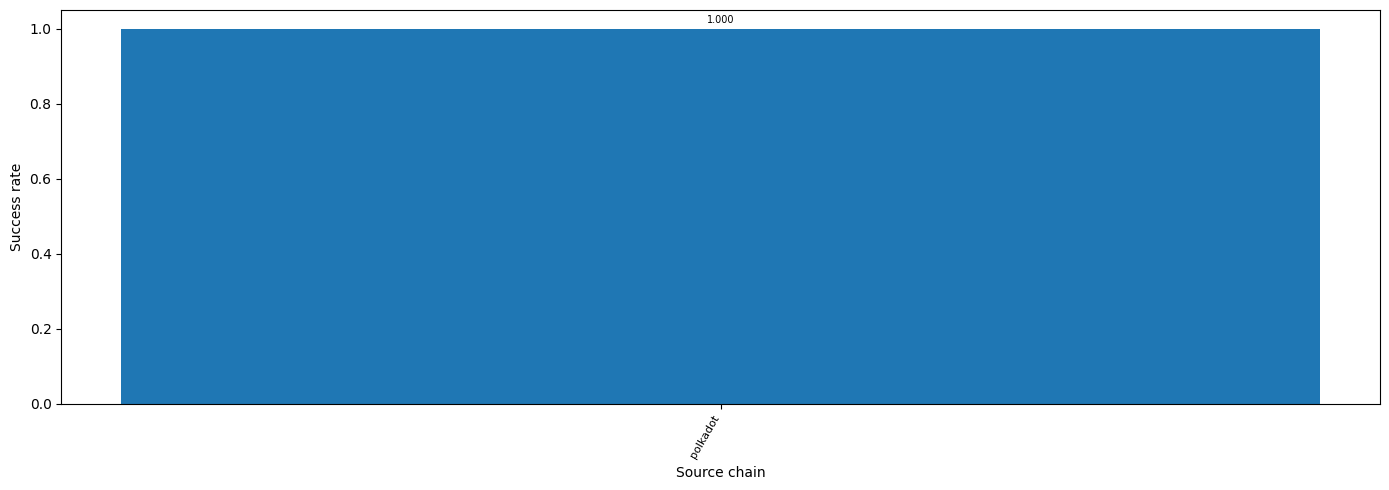

In [9]:
# -------------------------
# 6) Reliability by source_chain
# -------------------------
rel_by_src = None
if "source_chain" in df_clean.columns:
    rows = []
    for chain, sub in df_clean.groupby("source_chain", dropna=False):
        r, s, f = compute_reliability(sub, SUCCESS_LABEL)
        rows.append([chain, r, s, f, len(sub)])
    rel_by_src = pd.DataFrame(rows, columns=["source_chain", "success_rate", "success_n", "failed_n", "total_n"])
    rel_by_src = rel_by_src.sort_values("success_rate", ascending=True)

    print("\nReliability by source_chain:")
    display(rel_by_src)

    plt.figure(figsize=(14, 5))
    plt.bar(rel_by_src["source_chain"].astype(str), rel_by_src["success_rate"])
    plt.ylim(0.0, 1.05)
    plt.ylabel("Success rate")
    plt.xlabel("Source chain")
    plt.xticks(rotation=60, ha="right", fontsize=8)
    for i, v in enumerate(rel_by_src["success_rate"].values):
        plt.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom", fontsize=7)
    plt.tight_layout()
    plt.show()

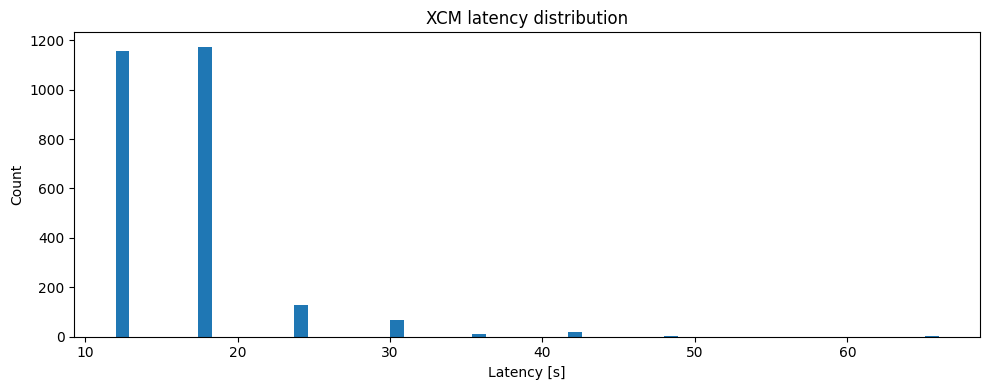

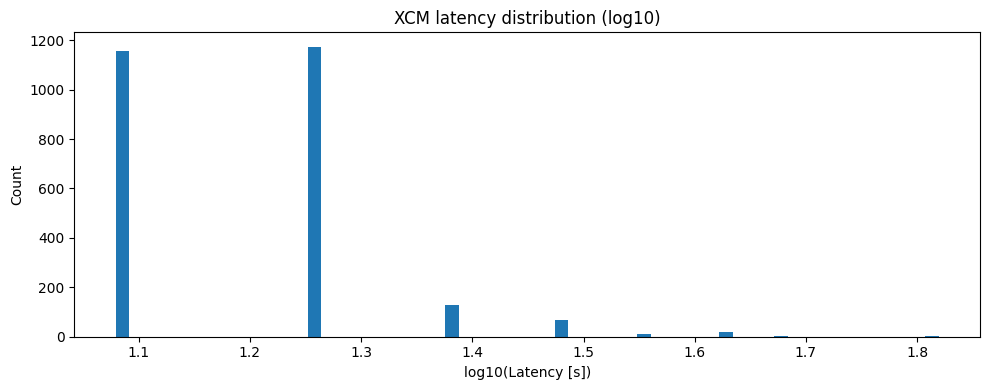

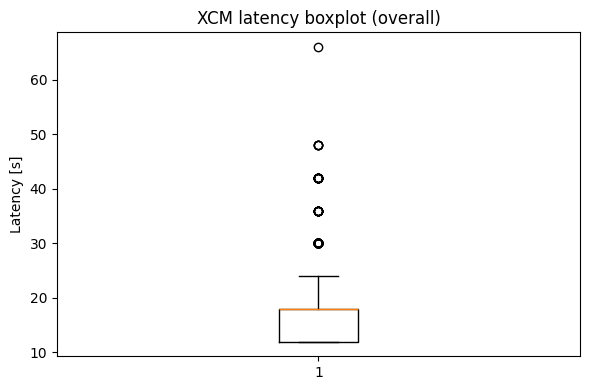

In [10]:
# -------------------------
# 7) Latency plots (distribution + log + box)
# -------------------------
plt.figure(figsize=(10, 4))
plt.hist(lat, bins=60)
plt.xlabel("Latency [s]")
plt.ylabel("Count")
plt.title("XCM latency distribution")
plt.tight_layout()
plt.show()

lat_pos = lat[lat > 0]
plt.figure(figsize=(10, 4))
plt.hist(np.log10(lat_pos), bins=60)
plt.xlabel("log10(Latency [s])")
plt.ylabel("Count")
plt.title("XCM latency distribution (log10)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.boxplot(lat.dropna(), vert=True, showfliers=True)
plt.ylabel("Latency [s]")
plt.title("XCM latency boxplot (overall)")
plt.tight_layout()
plt.show()

/var/folders/jc/s89dfxyj5t3fp9t3v2f1rg480000gn/T/ipykernel_36832/1977891365.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=chains, showfliers=False)


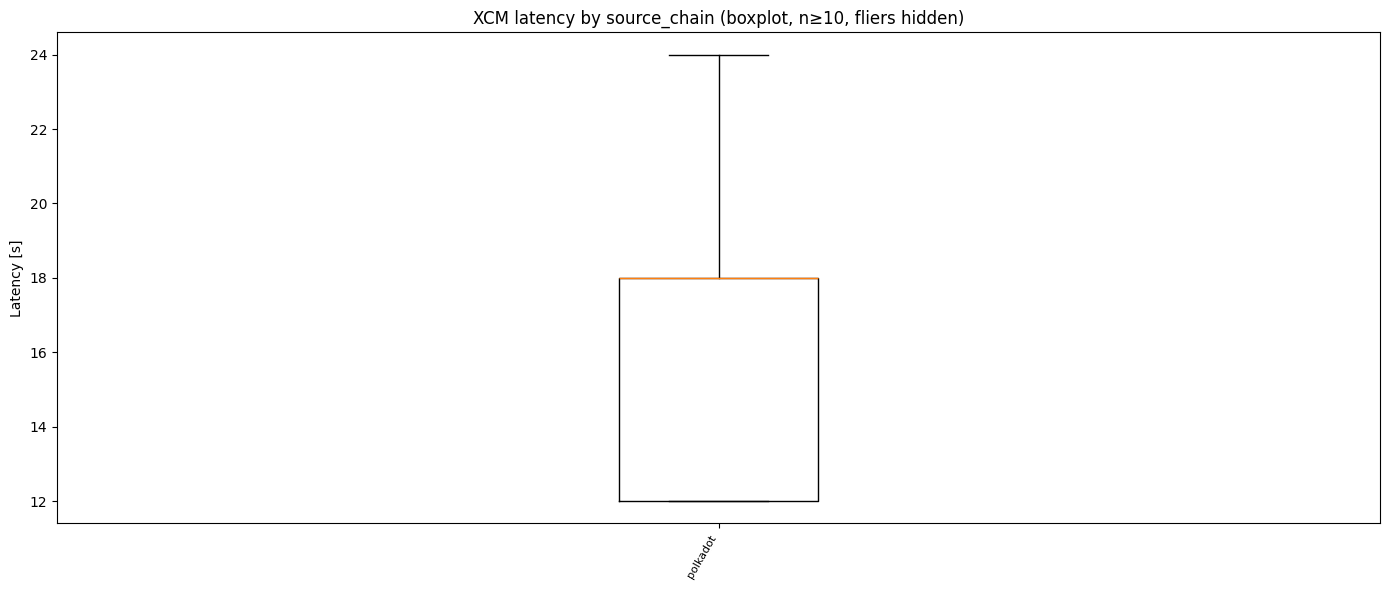

In [11]:
# -------------------------
# 8) Latency by chain (boxplots)
# -------------------------
if "source_chain" in df_clean.columns:
    counts = df_clean["source_chain"].value_counts()
    chains = counts[counts >= MIN_N_PER_CHAIN].index.tolist()

    data = [df_clean.loc[df_clean["source_chain"] == c, "latency_s"].dropna().values for c in chains]

    plt.figure(figsize=(14, 6))
    plt.boxplot(data, labels=chains, showfliers=False)
    plt.ylabel("Latency [s]")
    plt.title(f"XCM latency by source_chain (boxplot, n≥{MIN_N_PER_CHAIN}, fliers hidden)")
    plt.xticks(rotation=60, ha="right", fontsize=8)
    plt.tight_layout()
    plt.show()


Cost (RAW units) summary:


count    2.559000e+03
mean     1.828779e+08
std      1.348318e+07
min      0.000000e+00
50%      1.816335e+08
90%      2.076783e+08
99%      2.096783e+08
max      3.076663e+08
Name: cost, dtype: float64


Cost quantiles (RAW):


,Kvantil,Cost [raw]
0,p50,181633495.0
1,p90,207678305.0
2,p99,209678305.0


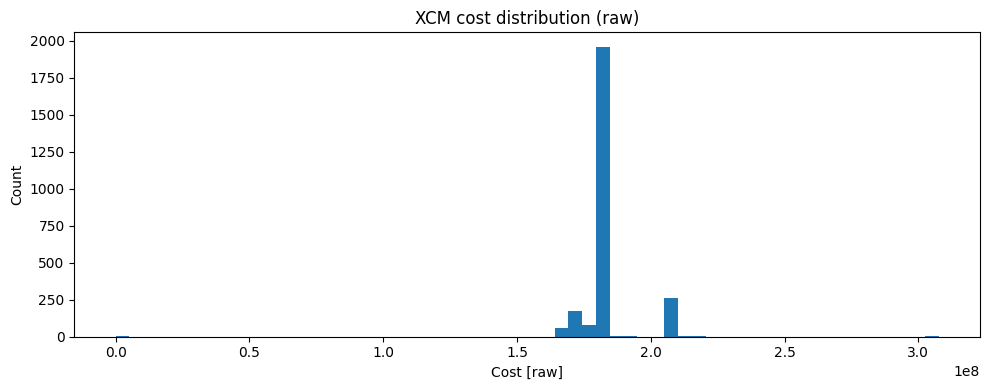


Sanity check (assumed planck->DOT->USD conversion):


,cost,cost_dot_assumed,cost_usd_assumed
count,2.559000e+03,2559.000000,2559.000000
mean,1.828779e+08,0.018288,0.024482
std,1.348318e+07,0.001348,0.001805
min,0.000000e+00,0.000000,0.000000
50%,1.816335e+08,0.018163,0.024315
90%,2.076783e+08,0.020768,0.027802
99%,2.096783e+08,0.020968,0.028070
max,3.076663e+08,0.030767,0.041187


Rows with assumed cost_usd > 10 USD: 0

Cost quantiles (USD, assumed):


,Kvantil,Cost [USD] (assumed)
0,p50,0.024315
1,p90,0.027802
2,p99,0.028070


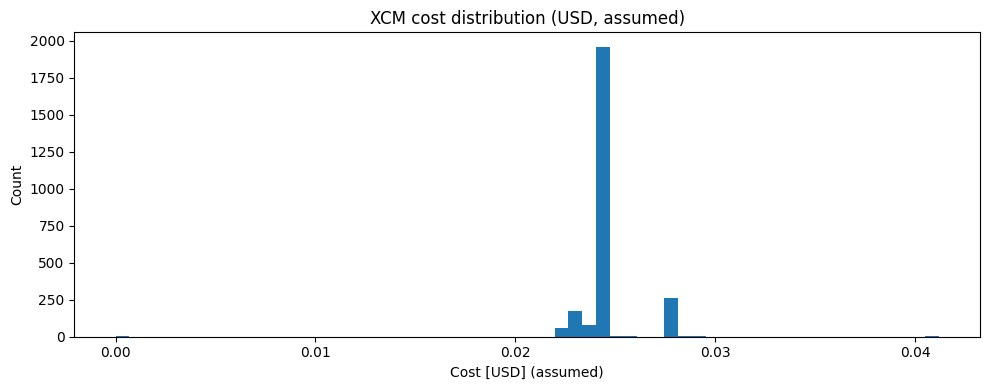


Average cost by source_chain (RAW):


,source_chain,avg_cost_raw
0,polkadot,1.828779e+08


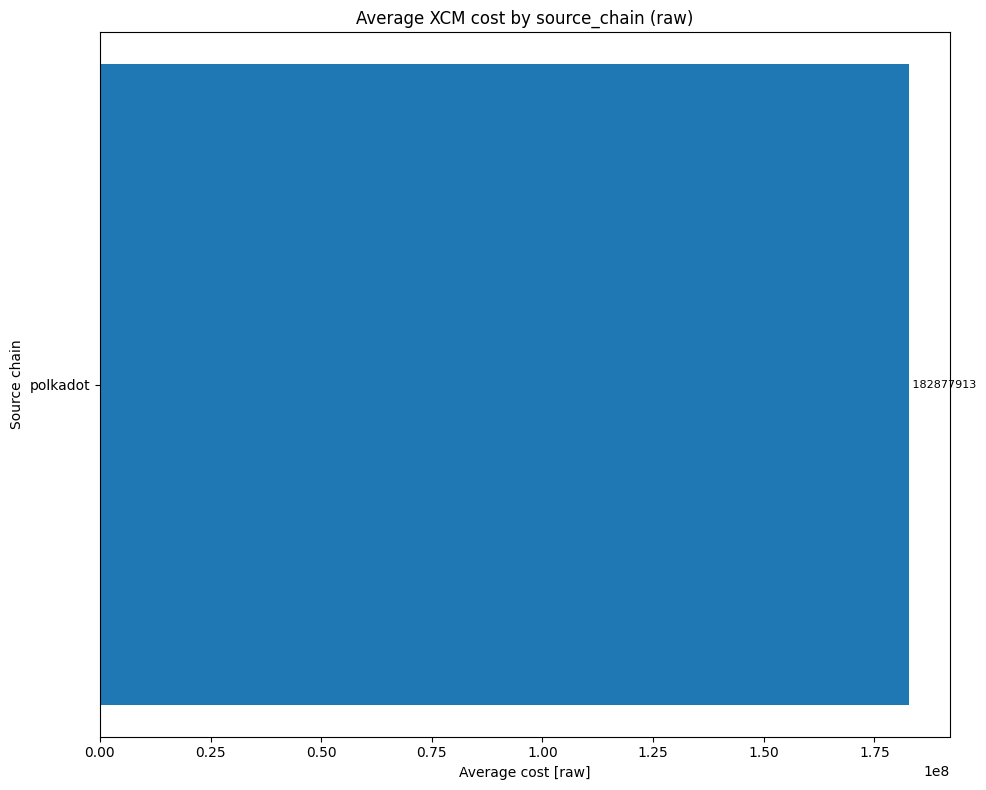


Average cost by source_chain (USD, assumed):


,source_chain,avg_cost_usd_assumed
0,polkadot,0.024482


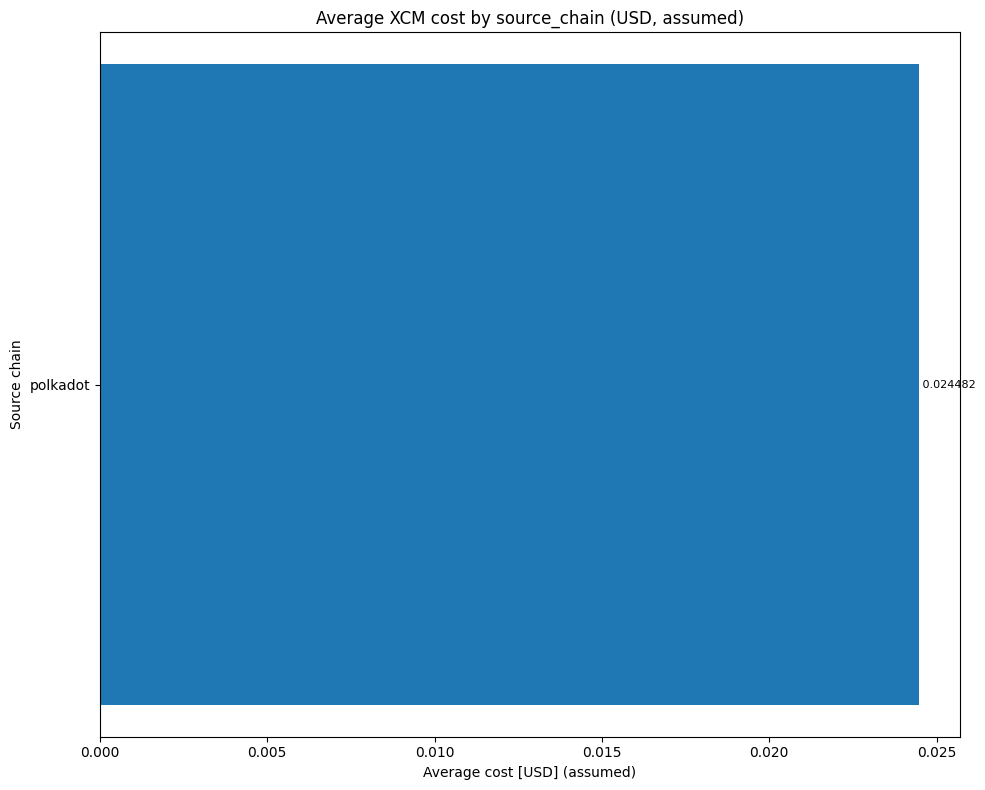

In [12]:
# -------------------------
# 9) Cost analysis — RAW + USD conversion
# -------------------------
if "cost" in df_clean.columns:
    # RAW summary
    cost_raw = df_clean["cost"].dropna()
    print("\nCost (RAW units) summary:")
    display(cost_raw.describe(percentiles=[0.5, 0.9, 0.99]))

    # RAW quantiles
    cq50, cq90, cq99 = np.percentile(cost_raw, [50, 90, 99])
    cost_quantiles_raw = pd.DataFrame({
        "Kvantil": ["p50", "p90", "p99"],
        "Cost [raw]": [cq50, cq90, cq99]
    })
    cost_quantiles_raw["Cost [raw]"] = cost_quantiles_raw["Cost [raw]"].map(lambda x: float(np.round(x, 2)))
    print("\nCost quantiles (RAW):")
    display(cost_quantiles_raw)

    plt.figure(figsize=(10, 4))
    plt.hist(cost_raw, bins=60)
    plt.xlabel("Cost [raw]")
    plt.ylabel("Count")
    plt.title("XCM cost distribution (raw)")
    plt.tight_layout()
    plt.show()

    # Assumed conversion: planck -> DOT -> USD
    df_clean["cost_dot_assumed"] = df_clean["cost"] / PLANCK_PER_DOT
    df_clean["cost_usd_assumed"] = df_clean["cost_dot_assumed"] * DOT_USD

    print("\nSanity check (assumed planck->DOT->USD conversion):")
    display(df_clean[["cost", "cost_dot_assumed", "cost_usd_assumed"]].describe(percentiles=[0.5, 0.9, 0.99]))

    suspicious = df_clean[df_clean["cost_usd_assumed"] > SUSPICIOUS_USD_THRESHOLD]
    print(f"Rows with assumed cost_usd > {SUSPICIOUS_USD_THRESHOLD} USD: {len(suspicious)}")
    if len(suspicious) > 0:
        cols = [c for c in ["source_chain", "dest_chain", "cost", "cost_usd_assumed", "latency_s", "corr_id"] if c in df_clean.columns]
        display(suspicious[cols].head(20))

    # USD quantiles table (Axelar-like)
    cost_usd = df_clean["cost_usd_assumed"].dropna()
    uq50, uq90, uq99 = np.percentile(cost_usd, [50, 90, 99])
    cost_quantiles_usd = pd.DataFrame({
        "Kvantil": ["p50", "p90", "p99"],
        "Cost [USD] (assumed)": [uq50, uq90, uq99]
    })
    cost_quantiles_usd["Cost [USD] (assumed)"] = cost_quantiles_usd["Cost [USD] (assumed)"].map(lambda x: float(np.round(x, 6)))
    print("\nCost quantiles (USD, assumed):")
    display(cost_quantiles_usd)

    plt.figure(figsize=(10, 4))
    plt.hist(cost_usd, bins=60)
    plt.xlabel("Cost [USD] (assumed)")
    plt.ylabel("Count")
    plt.title("XCM cost distribution (USD, assumed)")
    plt.tight_layout()
    plt.show()

    # Cost by source_chain — RAW
    if "source_chain" in df_clean.columns:
        costs_by_chain_raw = (
            df_clean.groupby("source_chain")["cost"]
            .mean()
            .sort_values(ascending=True)
            .reset_index()
            .rename(columns={"cost": "avg_cost_raw"})
        )
        print("\nAverage cost by source_chain (RAW):")
        display(costs_by_chain_raw)

        plt.figure(figsize=(10, 8))
        plt.barh(costs_by_chain_raw["source_chain"].astype(str), costs_by_chain_raw["avg_cost_raw"])
        plt.xlabel("Average cost [raw]")
        plt.ylabel("Source chain")
        plt.title("Average XCM cost by source_chain (raw)")
        for i, v in enumerate(costs_by_chain_raw["avg_cost_raw"].values):
            plt.text(v, i, f" {v:.0f}", va="center", fontsize=8)
        plt.tight_layout()
        plt.show()

        # Cost by source_chain — USD assumed (Axelar-style barh)
        costs_by_chain_usd = (
            df_clean.groupby("source_chain")["cost_usd_assumed"]
            .mean()
            .sort_values(ascending=True)
            .reset_index()
            .rename(columns={"cost_usd_assumed": "avg_cost_usd_assumed"})
        )
        print("\nAverage cost by source_chain (USD, assumed):")
        display(costs_by_chain_usd)

        plt.figure(figsize=(10, 8))
        plt.barh(costs_by_chain_usd["source_chain"].astype(str), costs_by_chain_usd["avg_cost_usd_assumed"])
        plt.xlabel("Average cost [USD] (assumed)")
        plt.ylabel("Source chain")
        plt.title("Average XCM cost by source_chain (USD, assumed)")
        for i, v in enumerate(costs_by_chain_usd["avg_cost_usd_assumed"].values):
            plt.text(v, i, f" {v:.6f}", va="center", fontsize=8)
        plt.tight_layout()
        plt.show()

In [13]:
# -------------------------
# 10) Finalized flags summary (NOT time-to-finality)
# -------------------------
if "finalized_src" in df_clean.columns and "finalized_dst" in df_clean.columns:
    fin_table = pd.DataFrame({
        "finalized_src=True": [(df_clean["finalized_src"] == True).sum()],
        "finalized_dst=True": [(df_clean["finalized_dst"] == True).sum()],
        "both_finalized=True": [((df_clean["finalized_src"] == True) & (df_clean["finalized_dst"] == True)).sum()],
        "total_rows": [len(df_clean)]
    })
    print("\nFinalized flags (sanity indicators):")
    display(fin_table)



Finalized flags (sanity indicators):


,finalized_src=True,finalized_dst=True,both_finalized=True,total_rows
0,2559,2559,2559,2559


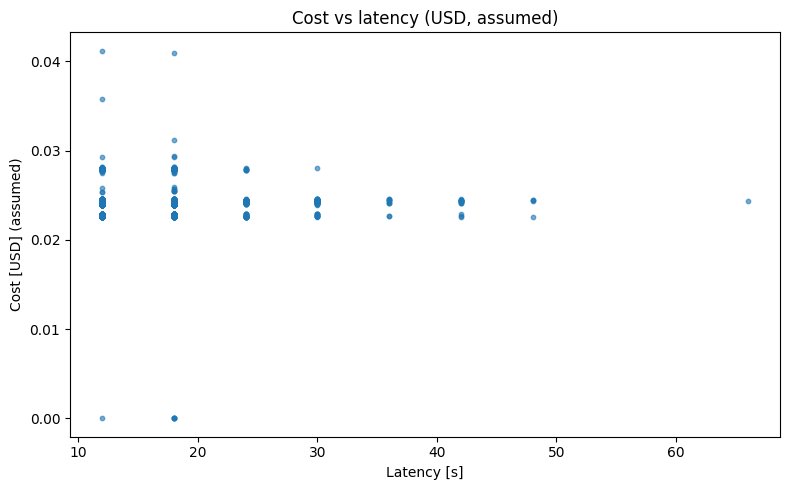

In [14]:
# -------------------------
# 11) Cost vs latency scatter (USD assumed)
# -------------------------
if "cost_usd_assumed" in df_clean.columns:
    d2 = df_clean.dropna(subset=["latency_s", "cost_usd_assumed"]).copy()
    if len(d2) > 0:
        plt.figure(figsize=(8, 5))
        plt.scatter(d2["latency_s"], d2["cost_usd_assumed"], s=10, alpha=0.6)
        plt.xlabel("Latency [s]")
        plt.ylabel("Cost [USD] (assumed)")
        plt.title("Cost vs latency (USD, assumed)")
        plt.tight_layout()
        plt.show()


In [15]:
# -------------------------
# 12) Extra: Chain-pair matrix overview (optional, useful for describing the sample)
# -------------------------
if "source_chain" in df_clean.columns and "dest_chain" in df_clean.columns:
    pair_counts = (
        df_clean.groupby(["source_chain", "dest_chain"])
        .size()
        .reset_index(name="n")
        .sort_values("n", ascending=False)
    )
    print("\nTop chain pairs by volume:")
    display(pair_counts.head(20))


Top chain pairs by volume:


,source_chain,dest_chain,n
1,polkadot,assethub,1702
0,polkadot,acala,857


In [17]:
    display(pair_counts.head(20))
# -------------------------
# 14) Important latency quantiles for each chain
# -------------------------

df_clean.groupby("dest_chain")["latency_s"].quantile([0.5,0.9,0.99]).unstack()


,source_chain,dest_chain,n
1,polkadot,assethub,1702
0,polkadot,acala,857


,0.50,0.90,0.99
dest_chain,,,
acala,18.0,30.0,42.0
assethub,18.0,18.0,24.0


In [18]:
# -------------------------
# 14) Important cost quantiles for each chain
# -------------------------

df_clean.groupby("dest_chain")["cost_usd_assumed"].describe(percentiles=[0.5,0.9,0.99])

,count,mean,std,min,50%,90%,99%,max
dest_chain,,,,,,,,
acala,857.0,0.023894,0.000724,0.022575,0.024315,0.024449,0.024583,0.025520
assethub,1702.0,0.024778,0.002091,0.000000,0.024320,0.027802,0.028070,0.041187
